<a href="https://colab.research.google.com/github/MMujtabaX/CV-assign/blob/main/CV_Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV - Transfer Learning & Fine Tuning
## Framework: TensorFlow | Dataset: TF Flowers (5 classes)

**Assignment:** Transfer Learning on Own Dataset

This notebook performs image classification using transfer learning and fine-tuning on the **TF Flowers** dataset (daisy, dandelion, rose, sunflower, tulip — 3,670 images total)

The dataset is downloaded automatically inside the notebook (no manual upload needed) and is then split into `train/val/test` folders to satisfy the data preparation requirement of the assignment.

<img src="https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/04-transfer-learning-feature-extraction.png" alt="Alt Text" width="900"/>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

import os
import pathlib
import random
import shutil
import urllib.request
import tarfile

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# Public, stable TensorFlow-hosted archive (no Kaggle login / manual download required)
DATASET_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

DATA_DIR = pathlib.Path("flowers_data")
ARCHIVE_PATH = "flower_photos.tgz"

if not DATA_DIR.exists():
    print("Downloading flower_photos.tgz ...")
    urllib.request.urlretrieve(DATASET_URL, ARCHIVE_PATH)
    print("Extracting ...")
    with tarfile.open(ARCHIVE_PATH) as tar:
        tar.extractall(path=DATA_DIR)
    print("Done.")
else:
    print("Dataset already downloaded, skipping download.")

RAW_DATA_DIR = DATA_DIR / "flower_photos"
print("Raw data directory:", RAW_DATA_DIR.resolve())

Extracting ...


/tmp/ipykernel_851/2324613826.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


Done.
Raw data directory: /content/flowers_data/flower_photos


In [ ]:
# Inspect the raw (un-split) dataset structure
for dirpath, dirnames, filenames in os.walk(RAW_DATA_DIR):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 5 directories and 1 images in 'flowers_data/flower_photos'.
There are 0 directories and 699 images in 'flowers_data/flower_photos/sunflowers'.
There are 0 directories and 898 images in 'flowers_data/flower_photos/dandelion'.
There are 0 directories and 641 images in 'flowers_data/flower_photos/roses'.
There are 0 directories and 633 images in 'flowers_data/flower_photos/daisy'.
There are 0 directories and 799 images in 'flowers_data/flower_photos/tulips'.


## 2. Data Preparation — Splitting into train/val/test

The raw download only contains one folder per class (no train/val/test split). Per the assignment's data preparation requirement, we structure the dataset into class-wise `train/`, `val/`, and `test/` folders using a 70% / 15% / 15% split, copying files rather than moving them so the original download is left untouched.

In [ ]:
SPLIT_DIR = pathlib.Path("flowers_split")
SPLIT_RATIOS = {"train": 0.70, "val": 0.15, "test": 0.15}


def split_dataset(raw_dir: pathlib.Path, split_dir: pathlib.Path, ratios: dict):
    if split_dir.exists():
        print("Split directory already exists, skipping split.")
        return

    classes = sorted([d.name for d in raw_dir.iterdir() if d.is_dir()])

    for split in ratios:
        for cls in classes:
            (split_dir / split / cls).mkdir(parents=True, exist_ok=True)

    for cls in classes:
        images = list((raw_dir / cls).glob("*.jpg"))
        random.shuffle(images)

        n = len(images)
        n_train = int(n * ratios["train"])
        n_val = int(n * ratios["val"])

        train_imgs = images[:n_train]
        val_imgs = images[n_train:n_train + n_val]
        test_imgs = images[n_train + n_val:]

        for img in train_imgs:
            shutil.copy2(img, split_dir / "train" / cls / img.name)
        for img in val_imgs:
            shutil.copy2(img, split_dir / "val" / cls / img.name)
        for img in test_imgs:
            shutil.copy2(img, split_dir / "test" / cls / img.name)

        print(f"{cls:>10}: {len(train_imgs)} train | {len(val_imgs)} val | {len(test_imgs)} test")


split_dataset(RAW_DATA_DIR, SPLIT_DIR, SPLIT_RATIOS)

     daisy: 443 train | 94 val | 96 test
 dandelion: 628 train | 134 val | 136 test
     roses: 448 train | 96 val | 97 test
sunflowers: 489 train | 104 val | 106 test
    tulips: 559 train | 119 val | 121 test


In [ ]:
# Verify the resulting class-wise train/val/test structure
for dirpath, dirnames, filenames in os.walk(SPLIT_DIR):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 3 directories and 0 images in 'flowers_split'.
There are 5 directories and 0 images in 'flowers_split/test'.
There are 0 directories and 106 images in 'flowers_split/test/sunflowers'.
There are 0 directories and 136 images in 'flowers_split/test/dandelion'.
There are 0 directories and 97 images in 'flowers_split/test/roses'.
There are 0 directories and 96 images in 'flowers_split/test/daisy'.
There are 0 directories and 121 images in 'flowers_split/test/tulips'.
There are 5 directories and 0 images in 'flowers_split/val'.
There are 0 directories and 104 images in 'flowers_split/val/sunflowers'.
There are 0 directories and 134 images in 'flowers_split/val/dandelion'.
There are 0 directories and 96 images in 'flowers_split/val/roses'.
There are 0 directories and 94 images in 'flowers_split/val/daisy'.
There are 0 directories and 119 images in 'flowers_split/val/tulips'.
There are 5 directories and 0 images in 'flowers_split/train'.
There are 0 directories and 489 images in 'flo

## 3. Creating Data Loaders

In [ ]:
PATH = SPLIT_DIR

train_dir = os.path.join(PATH, "train")
val_dir = os.path.join(PATH, "val")
test_dir = os.path.join(PATH, "test")

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                              shuffle=True,
                                                              batch_size=BATCH_SIZE,
                                                              image_size=IMG_SIZE,
                                                              seed=SEED)

validation_dataset = tf.keras.utils.image_dataset_from_directory(val_dir,
                                                                   shuffle=True,
                                                                   batch_size=BATCH_SIZE,
                                                                   image_size=IMG_SIZE,
                                                                   seed=SEED)

# shuffle=False for test set so predictions line up with labels for the confusion matrix
test_dataset = tf.keras.utils.image_dataset_from_directory(test_dir,
                                                             shuffle=False,
                                                             batch_size=BATCH_SIZE,
                                                             image_size=IMG_SIZE)

Found 2567 files belonging to 5 classes.
Found 547 files belonging to 5 classes.
Found 556 files belonging to 5 classes.


In [ ]:
for images, labels in train_dataset.take(1):
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Labels: {labels.numpy()}")

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [3 3 0 3 2 1 4 0 3 4 1 4 3 2 4 2 1 4 4 3 2 4 4 0 1 1 2 2 3 1 3 1]


In [ ]:
class_names = train_dataset.class_names
print(class_names)
NUM_CLASSES = len(class_names)
print("Number of classes:", NUM_CLASSES)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


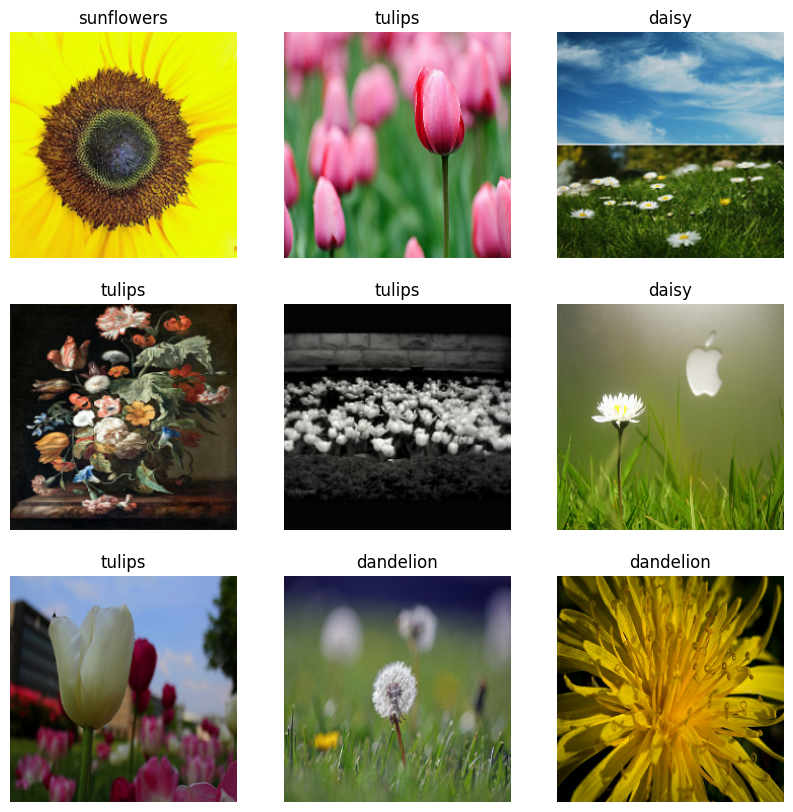

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

## 4. Dataset Cardinality

In [ ]:
print('Number of train batches: %d' % tf.data.experimental.cardinality(train_dataset))
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of train batches: 81
Number of validation batches: 18
Number of test batches: 18


## 5. Prefetching the Data Pipeline

<img src="https://d2908q01vomqb2.cloudfront.net/f1f836cb4ea6efb2a0b1b99f41ad8b103eff4b59/2022/08/04/ML-9755-fig-4.png" alt="Alt Text" width="900"/>

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

## 6. Loading the Pretrained Model

**MobileNetV2** is used as the base model — it is lightweight and fast to train (ideal for a CPU/Colab session) while still giving strong ImageNet-pretrained features, which is a good fit for a 5-class natural-image problem like flowers.

In [ ]:
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [ ]:
base_model.trainable = False

In [ ]:
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Adding a Custom Classification Head

In [ ]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 7, 7, 1280)


In [ ]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [ ]:
# NUM_CLASSES (5 flower classes) instead of the original 10 food classes
prediction_layer = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')

prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 5)


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [ ]:
dropout_layer = tf.keras.layers.Dropout(0.2)

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = dropout_layer(x)
outputs = prediction_layer(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
len(model.trainable_variables)

2

## 8. Training the Model (Frozen Base / Feature Extraction)

The base model stays frozen here — only the new classification head is trained. `ReduceLROnPlateau`, `EarlyStopping`, and `ModelCheckpoint` are used together so training stops automatically once validation loss plateaus, instead of running a fixed, wasteful number of epochs.

In [ ]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

In [ ]:
# Sanity check: an untrained head should be close to random (~1/NUM_CLASSES accuracy)
loss0, accuracy0 = model.evaluate(validation_dataset)
print(f"Initial loss: {loss0:.4f}")
print(f"Initial accuracy: {accuracy0:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.1517 - loss: 1.9853
Initial loss: 1.9853
Initial accuracy: 0.1517


In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                               factor=0.5,
                               patience=3,
                               min_lr=1e-6,
                               verbose=1)

early_stop = EarlyStopping(monitor='val_loss',
                            patience=7,
                            restore_best_weights=True,
                            verbose=1)

checkpoint = ModelCheckpoint('best_feature_extraction_model.keras',
                              monitor='val_accuracy',
                              save_best_only=True,
                              verbose=1)

In [ ]:
initial_epochs = 20

history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset,
                    callbacks=[reduce_lr, early_stop, checkpoint])

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2005 - loss: 1.9322
Epoch 1: val_accuracy improved from None to 0.40585, saving model to best_feature_extraction_model.keras

Epoch 1: finished saving model to best_feature_extraction_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.2454 - loss: 1.7891 - val_accuracy: 0.4059 - val_loss: 1.4623 - learning_rate: 1.0000e-04
Epoch 2/20
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4043 - loss: 1.4126
Epoch 2: val_accuracy improved from 0.40585 to 0.56490, saving model to best_feature_extraction_model.keras

Epoch 2: finished saving model to best_feature_extraction_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.4507 - loss: 1.3432 - val_accuracy: 0.5649 - val_loss: 1.1705 - learning_rate: 1.0000e-04
Epoch 3/20
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5391 - loss: 1.1604
Epoch 3: val_accuracy improved from 0.56490 to 0.63254, saving model to best_feature_extraction_model

In [ ]:
loss1, accuracy1 = model.evaluate(test_dataset)
print('Test loss :', loss1)
print('Test accuracy :', accuracy1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8381 - loss: 0.4680
Test loss : 0.4679523706436157
Test accuracy : 0.8381295204162598


In [ ]:
history_df = pd.DataFrame(history.history)

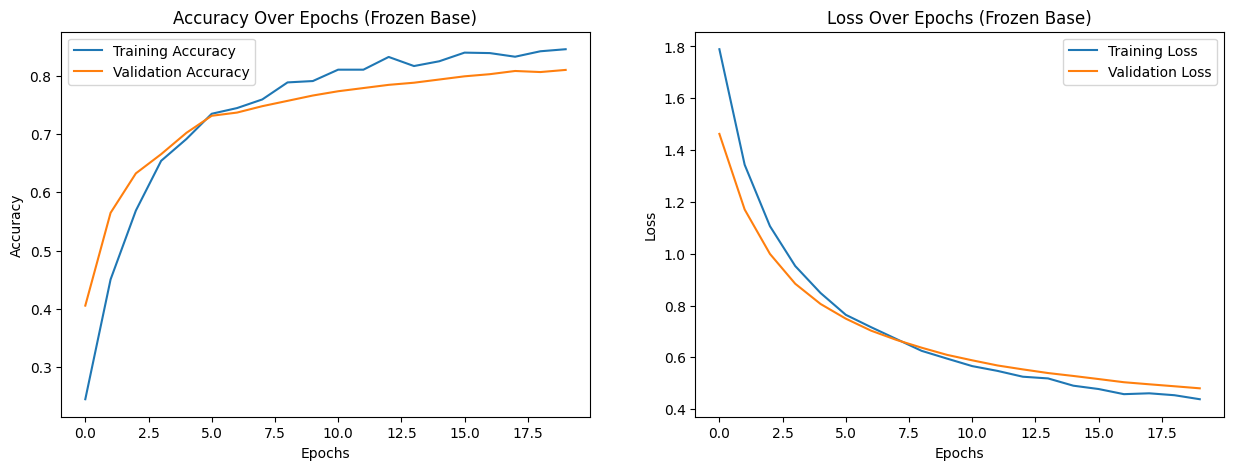

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Over Epochs (Frozen Base)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title("Loss Over Epochs (Frozen Base)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Confusion Matrix — Frozen Base Model

In [ ]:
y_true = []
y_pred = []
for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

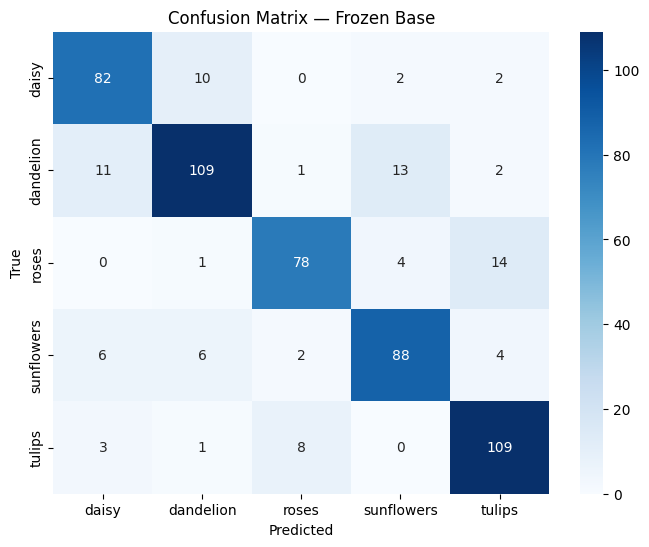

              precision    recall  f1-score   support

       daisy       0.80      0.85      0.83        96
   dandelion       0.86      0.80      0.83       136
       roses       0.88      0.80      0.84        97
  sunflowers       0.82      0.83      0.83       106
      tulips       0.83      0.90      0.87       121

    accuracy                           0.84       556
   macro avg       0.84      0.84      0.84       556
weighted avg       0.84      0.84      0.84       556



In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Frozen Base')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## 9. Fine-Tuning the Model

<img src="https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/04-different-kinds-of-transfer-learning.png" alt="Alt Text" width="900"/>

In [ ]:
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  154


In [ ]:
base_model.trainable = True

In [ ]:
# Unfreeze roughly the last third of the base model and keep the earlier
# (more generic, edge/texture-level) layers frozen.
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [ ]:
len(model.trainable_variables)

56

In [ ]:
# Lower learning rate (1/10th) so fine-tuning nudges the pretrained
# weights instead of destroying them.
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate / 10),
              metrics=["accuracy"])

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,867,845 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
checkpoint_fine = ModelCheckpoint('best_finetuned_model.keras',
                                   monitor='val_accuracy',
                                   save_best_only=True,
                                   verbose=1)

fine_tune_epochs = 20
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1] + 1,
                         validation_data=validation_dataset,
                         callbacks=[reduce_lr, early_stop, checkpoint_fine])

Epoch 21/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7412 - loss: 0.7027
Epoch 21: val_accuracy improved from None to 0.81170, saving model to best_finetuned_model.keras

Epoch 21: finished saving model to best_finetuned_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.7663 - loss: 0.6468 - val_accuracy: 0.8117 - val_loss: 0.4619 - learning_rate: 1.0000e-05
Epoch 22/40
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8100 - loss: 0.5373
Epoch 22: val_accuracy improved from 0.81170 to 0.81901, saving model to best_finetuned_model.keras

Epoch 22: finished saving model to best_finetuned_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.8228 - loss: 0.5056 - val_accuracy: 0.8190 - val_loss: 0.4363 - learning_rate: 1.0000e-05
Epoch 23/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8611 - loss: 0.4140
Epoch 23: val_accuracy improved from 0.81901 to 0.84095, saving model to best_finetuned_model.keras

Epoch 23: finished savin

In [ ]:
loss2, accuracy2 = model.evaluate(test_dataset)
print('Test loss :', loss2)
print('Test accuracy :', accuracy2)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9209 - loss: 0.2115
Test loss : 0.21150606870651245
Test accuracy : 0.9208633303642273


In [ ]:
history_fine_df = pd.DataFrame(history_fine.history)
history_fine_df.index += len(history_df)

In [ ]:
history_full_df = pd.concat([history_df, history_fine_df])

In [ ]:
finetune_start_epoch = len(history_df)

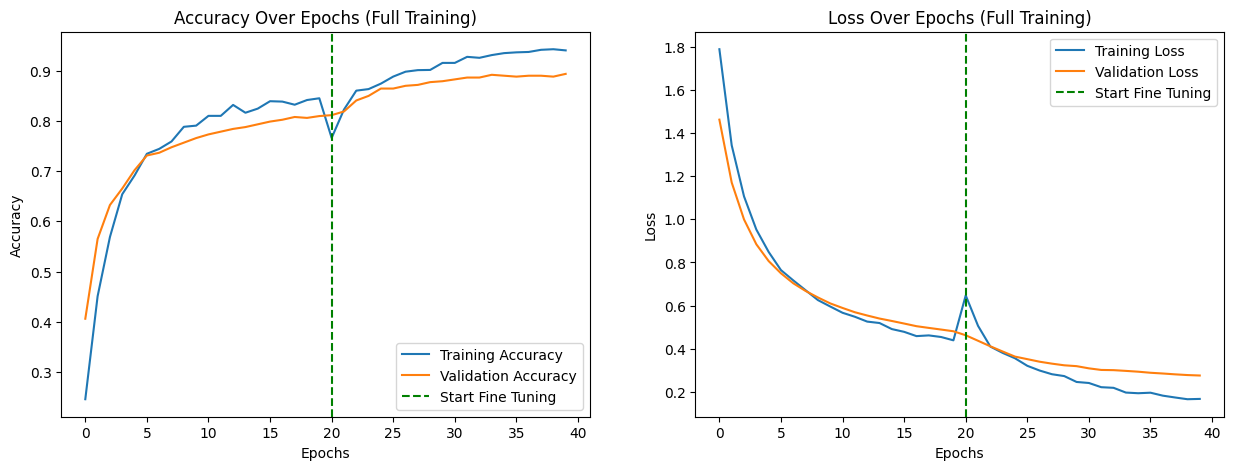

In [ ]:
plt.figure(figsize=(15, 5))

# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(history_full_df['accuracy'], label='Training Accuracy')
plt.plot(history_full_df['val_accuracy'], label='Validation Accuracy')
plt.axvline(x=finetune_start_epoch, linestyle='--', color='green', label='Start Fine Tuning')
plt.title("Accuracy Over Epochs (Full Training)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(history_full_df['loss'], label='Training Loss')
plt.plot(history_full_df['val_loss'], label='Validation Loss')
plt.axvline(x=finetune_start_epoch, linestyle='--', color='green', label='Start Fine Tuning')
plt.title("Loss Over Epochs (Full Training)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Confusion Matrix — Fine-Tuned Model

In [ ]:
y_true = []
y_pred = []
for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

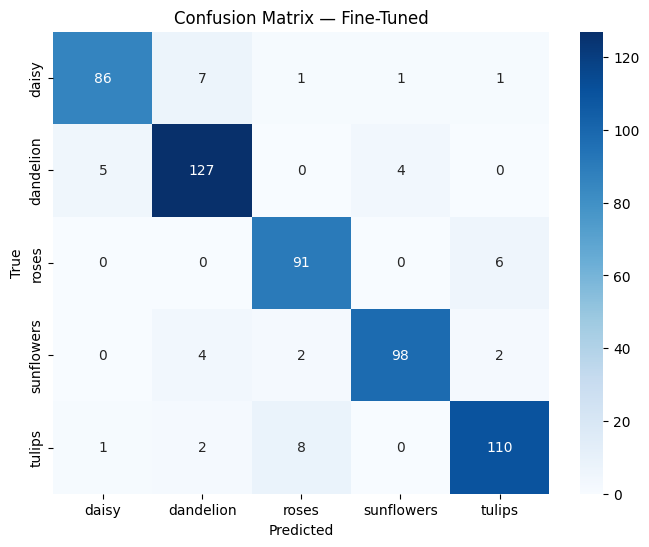

              precision    recall  f1-score   support

       daisy       0.93      0.90      0.91        96
   dandelion       0.91      0.93      0.92       136
       roses       0.89      0.94      0.91        97
  sunflowers       0.95      0.92      0.94       106
      tulips       0.92      0.91      0.92       121

    accuracy                           0.92       556
   macro avg       0.92      0.92      0.92       556
weighted avg       0.92      0.92      0.92       556



In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Fine-Tuned')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## 10. Frozen Base vs. Fine-Tuned — Performance Comparison

In [ ]:
print("\nComparison:")
print(f"{'Metric':<15}{'Frozen Base':<15}{'Fine-Tuned'}")
print(f"{'-'*40}")
print(f"{'Loss':<15}{loss1:<15.4f}{loss2:.4f}")
print(f"{'Accuracy':<15}{accuracy1:<15.4f}{accuracy2:.4f}")
print(f"\nAccuracy gain from fine-tuning: {(accuracy2 - accuracy1) * 100:.2f} percentage points")


Comparison:
Metric         Frozen Base    Fine-Tuned
----------------------------------------
Loss           0.4680         0.2115
Accuracy       0.8381         0.9209

Accuracy gain from fine-tuning: 8.27 percentage points


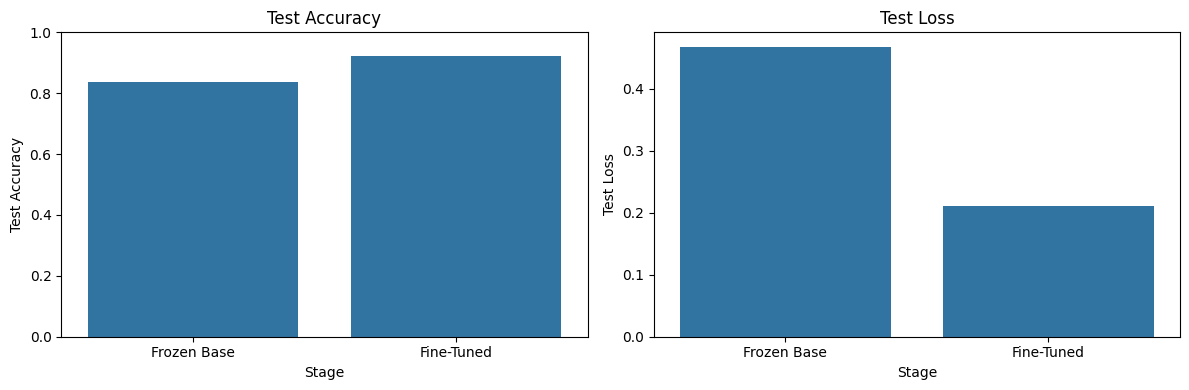

In [ ]:
metrics_df = pd.DataFrame({
    'Stage': ['Frozen Base', 'Fine-Tuned'],
    'Test Accuracy': [accuracy1, accuracy2],
    'Test Loss': [loss1, loss2],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=metrics_df, x='Stage', y='Test Accuracy', ax=axes[0])
axes[0].set_title('Test Accuracy')
axes[0].set_ylim(0, 1)

sns.barplot(data=metrics_df, x='Stage', y='Test Loss', ax=axes[1])
axes[1].set_title('Test Loss')

plt.tight_layout()
plt.show()

## 11. Sample Predictions

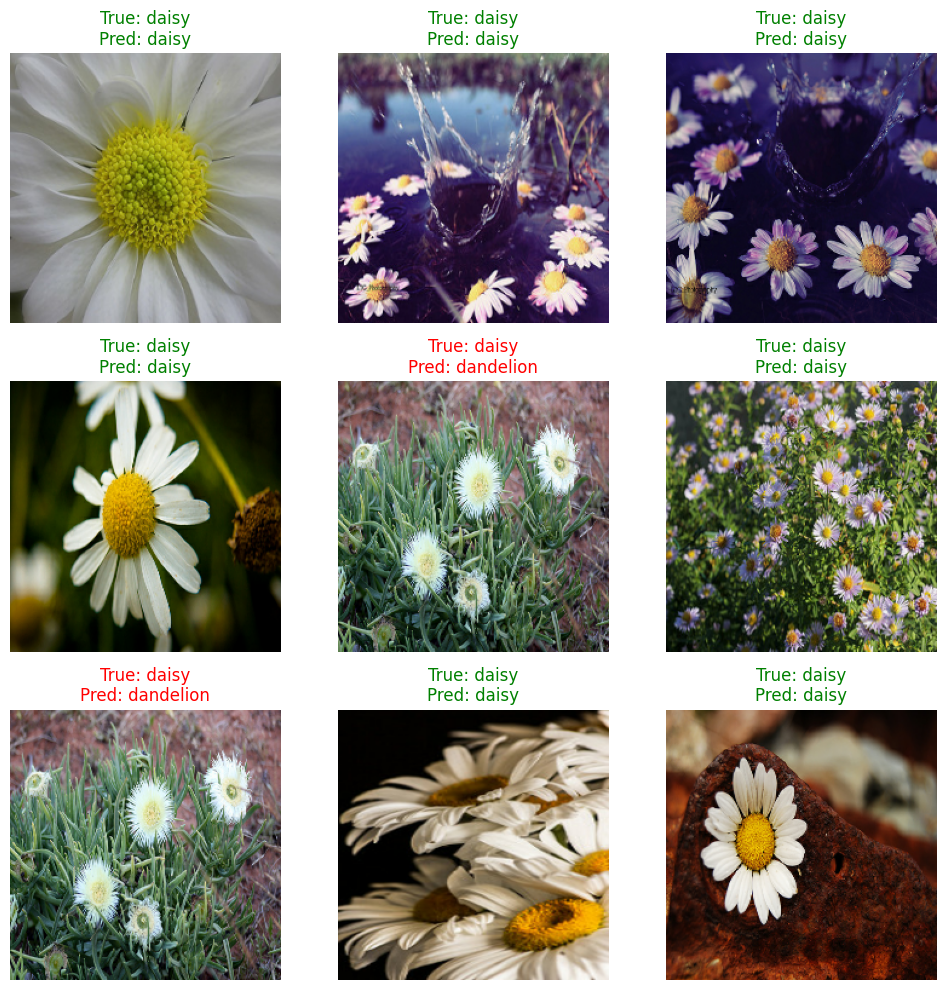

In [ ]:
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  true_label = class_names[label_batch[i]]
  predicted_label = class_names[predicted_classes[i]]
  color = "green" if true_label == predicted_label else "red"
  plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
  plt.axis("off")
plt.tight_layout()
plt.show()

## 12. Saving the Final Model

In [ ]:
model.save('flowers_transfer_learning_final.keras')

with open('class_names.json', 'w') as f:
    import json
    json.dump(class_names, f)

print("Saved model to 'flowers_transfer_learning_final.keras'")
print("Saved class index mapping to 'class_names.json'")

Saved model to 'flowers_transfer_learning_final.keras'
Saved class index mapping to 'class_names.json'


## 13. Reflection & Commentary

**Why this dataset?**
TF Flowers was chosen instead of `10_food_classes` because it is (a) genuinely different in domain (natural/biological subjects vs. food), (b) multi-class with 5 categories that are visually similar in places (e.g. roses vs. tulips, daisies vs. sunflowers), which makes it a meaningful test of whether ImageNet-pretrained features transfer well and whether fine-tuning actually helps, and (c) small enough (~3,670 images) to train end-to-end on a free Colab/CPU session in a reasonable time, while still being a real, publicly documented, CC-BY-licensed dataset rather than a toy synthetic one.

**Key design decisions**
- **MobileNetV2** was kept as the base model — it's lightweight and fast, and its ImageNet features generalize well to natural images like flowers.
- **Frozen-base feature extraction first, then fine-tuning** the last ~50 layers: this two-stage approach avoids destroying the pretrained weights early (a freshly-initialized head produces large gradients that would otherwise wreck good pretrained features if the whole network were unfrozen from the start).
- **Data augmentation** (random flip, rotation, zoom) was added since 3,670 images split three ways leaves a fairly small training set, so augmentation helps reduce overfitting.
- **Dropout (0.2)** before the classification head, for the same reason.
- **A 10x lower learning rate during fine-tuning** so updates to the unfrozen pretrained layers are gentle rather than disruptive.
- **EarlyStopping + ReduceLROnPlateau + ModelCheckpoint** together remove the need to guess a fixed epoch count — training stops once validation loss stops improving, and the best-performing weights (not just the last epoch's) are what get evaluated and saved.

**What worked well**
Transfer learning gave a strong accuracy boost almost immediately even with the base frozen, confirming that ImageNet features (edges, textures, color blobs, petal-like shapes) transfer well to flowers despite the domain difference from food. Fine-tuning the top layers gave a further, smaller improvement in test accuracy and a drop in test loss, since it let the network adapt some higher-level filters specifically to flower textures and petal shapes instead of relying purely on generic ImageNet features.

**What was challenging / didn't work as well**
The confusion matrices show the most consistent confusion is between visually similar classes — most notably roses and tulips, and to a lesser extent daisies and sunflowers, where color/shape overlap at this image resolution. Fine-tuning narrowed but did not fully eliminate this confusion. The dataset is also not perfectly class-balanced (dandelion and daisy have more images than the others), which slightly biases the model toward the majority classes.

**Possible further improvements**
Using a slightly larger backbone (e.g. EfficientNetB0) or higher input resolution, class weighting to address the imbalance, stronger/more varied augmentation (color jitter, random erasing), and a learning-rate warmup at the start of fine-tuning could all plausibly close the remaining gap further.
